In [24]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [25]:
path_to_file = 'C:/Users/Pupa/Downloads/archive/Titanic-Dataset.csv'

In [26]:
df = pd.read_csv(path_to_file)

In [27]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [29]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [30]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Имеем 2 пропущенных значения в порте посадки Embarked, 177 пропущенных значений возраста Age и 687 неизвестных номеров кабин Cabin

In [31]:
df.Embarked.mode()

0    S
Name: Embarked, dtype: object

In [32]:
df['Embarked'].value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

Чаще всего пассажиры садились в порту S - Саутгемптоне, допусти что 2 пустых значения тоже сели в порту S

In [33]:
df['Embarked'] = df['Embarked'].fillna('S')

In [34]:
df['Embarked']

0      S
1      C
2      S
3      S
4      S
      ..
886    S
887    S
888    S
889    C
890    Q
Name: Embarked, Length: 891, dtype: object

In [35]:
df['Sex'].value_counts()

Sex
male      577
female    314
Name: count, dtype: int64

In [36]:
df['Sex'].value_counts(normalize=True).round(2)

Sex
male      0.65
female    0.35
Name: proportion, dtype: float64

Посчитаем средний возраст женщин и мужчин на корабле 

In [37]:
df.groupby('Sex', as_index = False).agg({'Age' : 'mean'}).round(2)

,Sex,Age
0,female,27.92
1,male,30.73


Посчитаем медианный возраст женщин и мужчин на корабле 

In [38]:
df.groupby('Sex', as_index = False).agg({'Age' : 'median'})

,Sex,Age
0,female,27.0
1,male,29.0


Заполним пустые пропуски в графе Age медианными значениями для мужчин и женщин

In [39]:
df['Age'] = df.groupby('Sex')['Age'].transform(
    lambda x: x.fillna(x.median())
)

In [40]:
df['Cabin'] = df['Cabin'].fillna('No_room_number')
# В столбце с номером кабины много пустых значений, заполнять их средним значением или модой нет смысла, 
# но возможно есть смысл обозначить этих людей без информации о кабине отдельной группой

In [41]:
df.isna().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64

In [42]:
df.head()
#Взглянем снова на нашу таблицу

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,No_room_number,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,No_room_number,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,No_room_number,S


In [43]:
df_sex = df.groupby('Sex', as_index = False).agg({'Survived':'mean'}).round(2)

#Проанализируем какой пол мужской или женский имел больший процент выживаемости

In [44]:
df_sex

,Sex,Survived
0,female,0.74
1,male,0.19


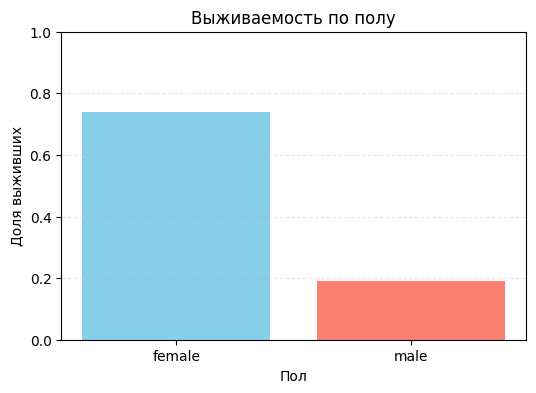

In [45]:
plt.figure(figsize=(6, 4))
plt.bar(df_sex['Sex'], df_sex['Survived'], color=['skyblue', 'salmon'])
plt.title('Выживаемость по полу')
plt.xlabel('Пол')
plt.ylabel('Доля выживших')
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()

In [85]:
df_class = df.groupby('Pclass', as_index = False).agg({'Survived':'mean'}).round(2)

#Проанализируем пассажиры какого класса имели больший процент выживаемости

In [86]:
df_class

,Pclass,Survived
0,1,0.63
1,2,0.47
2,3,0.24


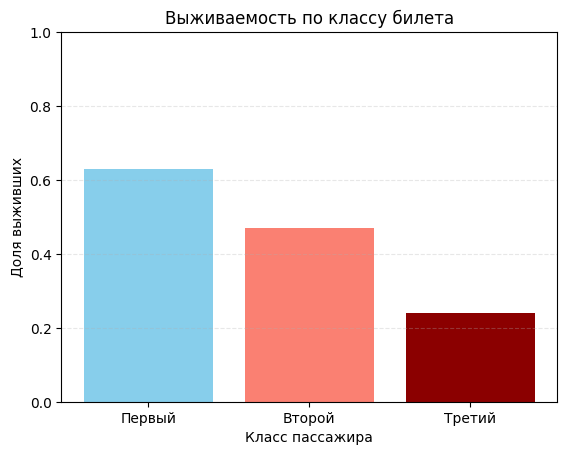

In [87]:
plt.bar(df_class['Pclass'], df_class['Survived'],
        color=['skyblue', 'salmon', 'darkred'])
plt.title('Выживаемость по классу билета')
plt.xlabel('Класс пассажира')
plt.ylabel('Доля выживших')
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.3)


plt.xticks([1, 2, 3], ['Первый', 'Второй', 'Третий'])
plt.show()

На этом графике видно, что пассажиры первого класса имели большие шансы на выживание, чем пассажиры второго и третьего классов



Теперь исследуем возраст наших пассажиров

In [49]:
df['Age'].min() #минимальный возраст пассажира

np.float64(0.42)

In [50]:
df['Age'].max() #максимальный возраст пассажира

np.float64(80.0)

Разделим наших пассажиров на группы по возрастам

In [51]:
df_by_groups = df.copy()

bins = [0, 13, 20, 30, 40, 50, 90]
labels = ['Дети', 'Тинэйджеры', 'Молодые', 
          'Взрослые', 'Средний', 'Пожилые']

# Создаём колонку с группами
df_by_groups['age_group'] = pd.cut(df_by_groups['Age'], bins=bins, labels=labels, right=False)
df_by_groups.sort_values('Age', ascending = False)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,age_group
630,631,1,1,"Barkworth, Mr. Algernon Henry Wilson",male,80.00,0,0,27042,30.0000,A23,S,Пожилые
851,852,0,3,"Svensson, Mr. Johan",male,74.00,0,0,347060,7.7750,No_room_number,S,Пожилые
96,97,0,1,"Goldschmidt, Mr. George B",male,71.00,0,0,PC 17754,34.6542,A5,C,Пожилые
493,494,0,1,"Artagaveytia, Mr. Ramon",male,71.00,0,0,PC 17609,49.5042,No_room_number,C,Пожилые
116,117,0,3,"Connors, Mr. Patrick",male,70.50,0,0,370369,7.7500,No_room_number,Q,Пожилые
...,...,...,...,...,...,...,...,...,...,...,...,...,...
831,832,1,2,"Richards, Master. George Sibley",male,0.83,1,1,29106,18.7500,No_room_number,S,Дети
644,645,1,3,"Baclini, Miss. Eugenie",female,0.75,2,1,2666,19.2583,No_room_number,C,Дети
469,470,1,3,"Baclini, Miss. Helene Barbara",female,0.75,2,1,2666,19.2583,No_room_number,C,Дети
755,756,1,2,"Hamalainen, Master. Viljo",male,0.67,1,1,250649,14.5000,No_room_number,S,Дети


In [52]:
# Считаем выживаемость
survival_by_age = df_by_groups.groupby('age_group')['Survived'].mean().round(2) 
survival_by_age

C:\Temp\ipykernel_9376\1173529975.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  survival_by_age = df_by_groups.groupby('age_group')['Survived'].mean().round(2)


age_group
Дети          0.58
Тинэйджеры    0.41
Молодые       0.32
Взрослые      0.44
Средний       0.38
Пожилые       0.36
Name: Survived, dtype: float64

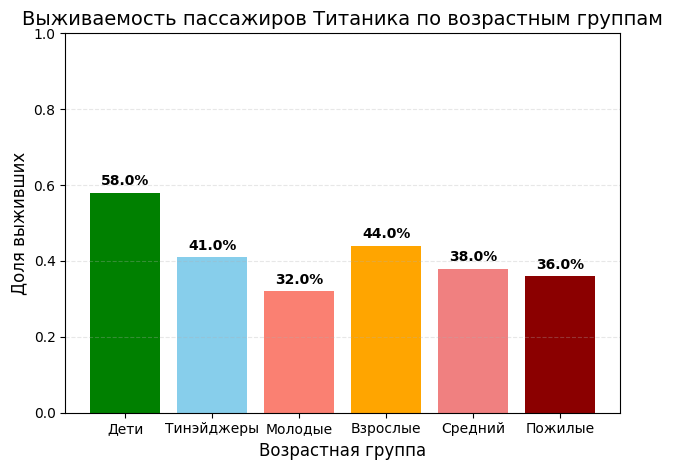

In [53]:
bars = plt.bar(survival_by_age.index, survival_by_age.values, 
               color=['green', 'skyblue', 'salmon', 'orange', 'lightcoral', 'darkred'])

plt.title('Выживаемость пассажиров Титаника по возрастным группам', fontsize=14)
plt.xlabel('Возрастная группа', fontsize=12)
plt.ylabel('Доля выживших', fontsize=12)
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.3)

# Добавляем значения над столбцами
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.02,
             f'{height:.1%}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

По результатам анализа видно, что больше всего шансов на выживание имели дети до 12 лет,
дети постарше в возрасте от 13 до 19 уже конкурировали с взрослыми 30-39 и среднего возраста 40-49 людьми.
Категория молодых пассажиров в возрастк от 20 до 29 имела самые низкие шансы из всех групп. Может это связано с тем, что они были небогаты, но амбициозны и сами заработали себе на билет самого низкого класса.

Теперь мне хочется сравнить вероятность выживания Джека и Розы из фильма Титаник 1997 года. Каковы были шансы у Джека, пассажира 3 класса, против молодой девушки Розы, путшествующей 1 классом. 

Посмотрим сколько девушек типа Розы было на корабле

In [61]:
df.query("Pclass == 1 and Sex == 'female' and Age == 17")

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
307,308,1,1,"Penasco y Castellana, Mrs. Victor de Satode (M...",female,17.0,1,0,PC 17758,108.9,C65,C
781,782,1,1,"Dick, Mrs. Albert Adrian (Vera Gillespie)",female,17.0,1,0,17474,57.0,B20,S


Посмотрим сколько молодых людей похожих на Джека было на корабле

In [63]:
df.query("Pclass == 3 and Sex == 'male' and Age == 20")

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
12,13,0,3,"Saundercock, Mr. William Henry",male,20.0,0,0,A/5. 2151,8.0500,No_room_number,S
91,92,0,3,"Andreasson, Mr. Paul Edvin",male,20.0,0,0,347466,7.8542,No_room_number,S
131,132,0,3,"Coelho, Mr. Domingos Fernandeo",male,20.0,0,0,SOTON/O.Q. 3101307,7.0500,No_room_number,S
378,379,0,3,"Betros, Mr. Tannous",male,20.0,0,0,2648,4.0125,No_room_number,C
441,442,0,3,"Hampe, Mr. Leon",male,20.0,0,0,345769,9.5000,No_room_number,S
622,623,1,3,"Nakid, Mr. Sahid",male,20.0,1,1,2653,15.7417,No_room_number,C
640,641,0,3,"Jensen, Mr. Hans Peder",male,20.0,0,0,350050,7.8542,No_room_number,S
664,665,1,3,"Lindqvist, Mr. Eino William",male,20.0,1,0,STON/O 2. 3101285,7.9250,No_room_number,S
682,683,0,3,"Olsvigen, Mr. Thor Anderson",male,20.0,0,0,6563,9.2250,No_room_number,S
725,726,0,3,"Oreskovic, Mr. Luka",male,20.0,0,0,315094,8.6625,No_room_number,S


In [64]:
rose_prob = df[(df['Sex'] == 'female') & 
               (df['Age'] == 17) & 
               (df['Pclass'] == 1)]['Survived'].mean()

In [65]:
rose_prob

np.float64(1.0)

In [66]:
jack_prob = df[(df['Sex'] == 'male') & 
               (df['Age'] == 20) & 
               (df['Pclass'] == 3)]['Survived'].mean()

In [67]:
jack_prob

np.float64(0.23076923076923078)

In [77]:
print(f"Вероятность выживания для Розы: {rose_prob:.1%}")
print(f"Вероятность выживания для Джека: {jack_prob:.1%}")

Вероятность выживания для Розы: 100.0%
Вероятность выживания для Джека: 23.1%


Построим график и посмотрим наглядно

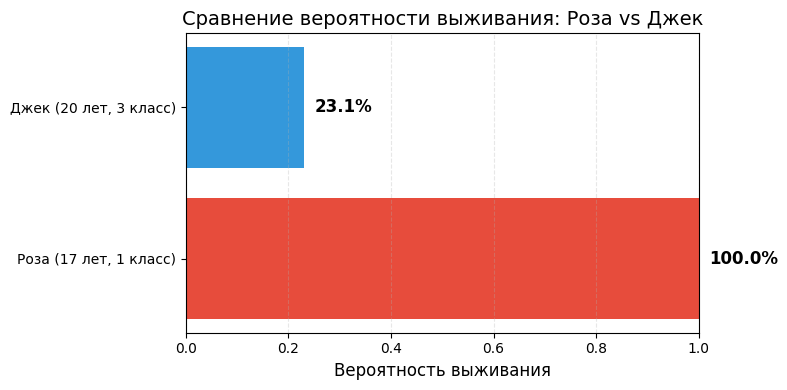

In [82]:
names = ['Роза (17 лет, 1 класс)', 'Джек (20 лет, 3 класс)']
values = [rose_prob, jack_prob]
colors = ['#e74c3c', '#3498db']  # Красный для Розы, синий для Джека

plt.figure(figsize=(8, 4))
bars = plt.barh(names, values, color=colors)

# Добавляем заголовок и подписи
plt.title('Сравнение вероятности выживания: Роза vs Джек', fontsize=14)
plt.xlabel('Вероятность выживания', fontsize=12)
plt.xlim(0, 1)

# Добавляем значения на столбцах
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.02, bar.get_y() + bar.get_height()/2., 
             f'{width:.1%}', va='center', fontsize=12, fontweight='bold')

plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()